In [130]:
import numpy as np
import matplotlib.pyplot as plt

# Define a 2D PSD quadratic function: f(x) = 0.5 x^T Q x + b^T x + c
Q = np.array([[10, 0], [0, 1]])  # symmetric and positive semi-definite
# Rotate Q randomly via an orthogonal transformation
# theta = -45
# R = np.array([[np.cos(theta), -np.sin(theta)],
#               [np.sin(theta),  np.cos(theta)]])
# Q = R.T @ Q @ R
b = np.array([0.0, 0.0])
c = 0.0

def f(x):
    return 0.5 * x.T @ Q @ x + b.T @ x + c

# Generate grid of points
xrange = np.linspace(-.1, .1, 200)
yrange = np.linspace(-.1, .1, 200)
X, Y = np.meshgrid(xrange, yrange)
Z = np.zeros_like(X)

# Compute function value on the grid
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x_ = np.array([X[i,j], Y[i,j]])
        Z[i,j] = f(x_)

# Choose a starting point within the plotting range
rng = np.random.default_rng()
x0 = np.array([-.095, .095])

# Compute gradient at x: grad f(x) = Qx + b
def grad_f(x):
    return Q @ x + b

# Compute the analytical minimum (global minimizer) for quadratic: x* = -Q^{-1}b
x_star = np.linalg.solve(Q, -b)  # for visualization; here b=0, so x*=0

# Pick a step size (learning rate): use 1/L
L = np.linalg.eigvalsh(Q).max()  # Lipschitz constant (largest eigenvalue of Q)
mu = np.linalg.eigvalsh(Q).min()  # Lipschitz constant (largest eigenvalue of Q)
eta = (1/L) * 1.2

# Perform 10 steps of gradient descent, storing optimization path
n_steps = 10
x_path_vanilla = [x0]
x_curr = x0.copy()
for k in range(n_steps):
    x_next = x_curr - eta * grad_f(x_curr)
    x_path_vanilla.append(x_next)
    x_curr = x_next
x_path_vanilla = np.array(x_path_vanilla)

x_path_nest = [x0, x_path_vanilla[1]]  # Nesterov needs 2 initial points (copy initial twice for simplicity)
x_curr = x0.copy()
y_path_nest = [x0]
d_path_nest = [np.zeros_like(x0)]
beta = lambda k: (k-1)/(k+2)
for k in range(1, n_steps):
    y_curr = x_curr + beta(k) * (x_curr - x_path_nest[-2])
    x_next = y_curr - eta * grad_f(y_curr)
    y_path_nest.append(y_curr)
    d_path_nest.append(eta * grad_f(y_curr))
    x_path_nest.append(x_next)
    x_curr = x_next
x_path_nest = np.array(x_path_nest)

x_path_phb = [x0, x_path_vanilla[1]]  # Nesterov needs 2 initial points (copy initial twice for simplicity)
x_curr = x0.copy()
y_path_phb = [x0]
d_path_phb = [np.zeros_like(x0)]
beta = lambda k: ((np.sqrt(L)-np.sqrt(mu))/(np.sqrt(L)+  np.sqrt(mu)))**2
for k in range(1, n_steps):
    y_curr = x_curr + beta(k) * (x_curr - x_path_phb[-2])
    x_next = y_curr - eta * grad_f(x_curr)
    y_path_phb.append(y_curr)
    d_path_phb.append(eta * grad_f(x_curr))
    x_path_phb.append(x_next)
    x_curr = x_next
x_path_phb = np.array(x_path_phb)






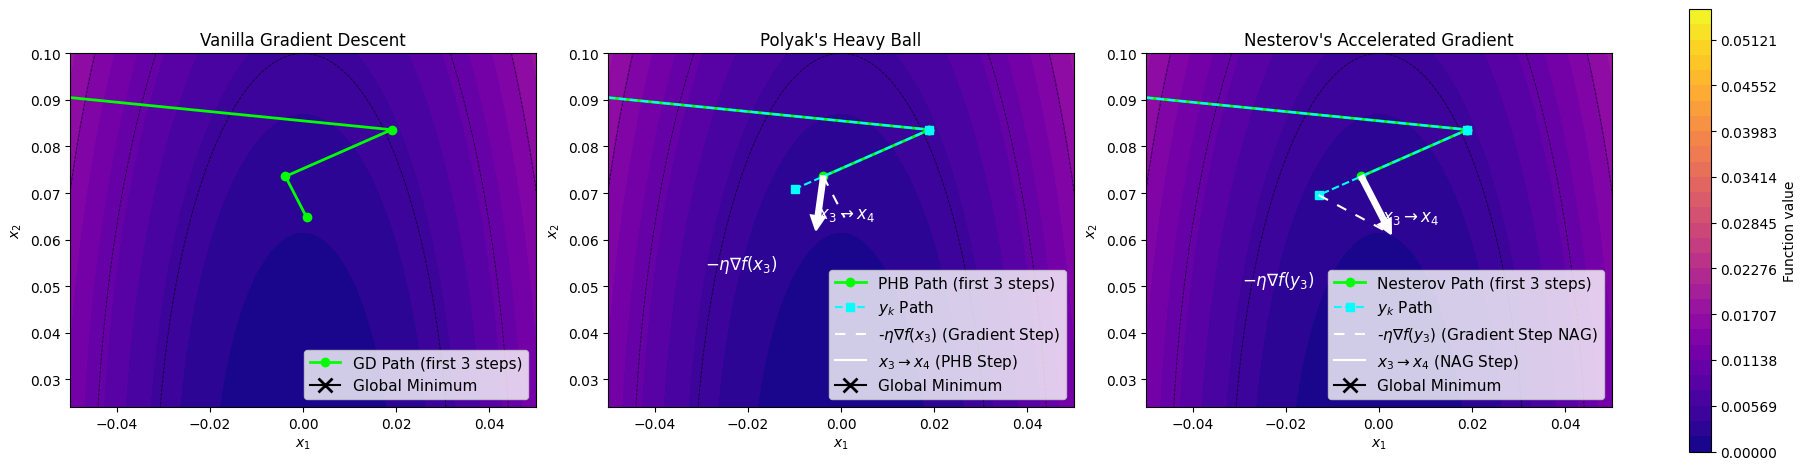

In [131]:
# Plot optimization paths (show only first 3 steps; for PHB and Nesterov also plot y_path)

import matplotlib.lines as mlines

# Get min and max of Z for color scaling
z_min, z_max = Z.min(), Z.max()

fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

Nplot = 3  # only plot first 3 steps

x_range_min, x_range_max = -0.050, 0.050  # Set x_range as required

# --------- VANILLA GD PLOT (axs[0]) ---------
h0 = axs[0].contourf(
    X, Y, Z, 
    levels=np.linspace(z_min, z_max, 30), 
    cmap="plasma", 
    vmin=z_min, vmax=z_max
)
axs[0].contour(X, Y, Z, levels=10, colors="k", linewidths=0.6, linestyles="--", alpha=0.7)
axs[0].set_title("Vanilla Gradient Descent")
axs[0].set_xlabel("$x_1$")
axs[0].set_ylabel("$x_2$")
axs[0].set_aspect('equal')
axs[0].set_ylim(0.0240, 0.1)
axs[0].set_xlim(x_range_min, x_range_max)
l0, = axs[0].plot(
    x_path_vanilla[:Nplot+1, 0],
    x_path_vanilla[:Nplot+1, 1],
    '-o', color='lime', linewidth=2, label=f"GD Path (first {Nplot} steps)"
)
l0_min, = axs[0].plot(x_star[0], x_star[1], marker='x', color='black', markersize=10, markeredgewidth=2, label="Global Minimum")

# Legend for GD
axs[0].legend(
    handles=[l0, l0_min],
    loc='lower right',
    fontsize=11,
    frameon=True
)

# --------- POLYAK'S HEAVY BALL PLOT (axs[1]) ---------
axs[1].contourf(
    X, Y, Z, 
    levels=np.linspace(z_min, z_max, 30), 
    cmap="plasma", 
    vmin=z_min, vmax=z_max
)
axs[1].contour(X, Y, Z, levels=10, colors="k", linewidths=0.6, linestyles="--", alpha=0.7)
axs[1].set_title("Polyak's Heavy Ball")
axs[1].set_xlabel("$x_1$")
axs[1].set_ylabel("$x_2$")
axs[1].set_aspect('equal')
axs[1].set_ylim(0.0240, 0.1)
axs[1].set_xlim(x_range_min, x_range_max)
l1, = axs[1].plot(
    x_path_phb[:Nplot+1, 0],
    x_path_phb[:Nplot+1, 1], 
    '-o', color='lime', linewidth=2, label=f"PHB Path (first {Nplot} steps)"
)
l1_y, = axs[1].plot(
    np.array(y_path_phb[:Nplot+1])[:, 0],
    np.array(y_path_phb[:Nplot+1])[:, 1],
    's--', color='cyan', linewidth=1.5, label="$y_k$ Path"
)

proxy_gradient_step = None
proxy_update_step = None
phb_handles = [l1, l1_y]
phb_labels = [l1.get_label(), l1_y.get_label()]

if len(x_path_phb) > 3:
    x2 = x_path_phb[2]
    x3 = x_path_phb[3]
    grad_x3 = grad_f(x3)
    eta_grad_x3 = eta * grad_x3
    betak = ((np.sqrt(L)-np.sqrt(mu))/(np.sqrt(L)+  np.sqrt(mu)))**2
    x4 = x_path_phb[4] if len(x_path_phb) > 4 else x3 - eta_grad_x3 + betak*(x3-x2)
    phb_gradient_head = x3 - eta_grad_x3
    line1, = axs[1].plot(
        [x3[0], phb_gradient_head[0]],
        [x3[1], phb_gradient_head[1]],
        linestyle=(0, (5, 5)), color='white', linewidth=1.5, label="-$\\eta\\nabla f(x_3)$ (Gradient Step)", zorder=11
    )
    proxy_gradient_step = mlines.Line2D([0,1], [0,0], color='white', linewidth=1.5, linestyle=(0, (5,5)), label="-$\\eta\\nabla f(x_3)$ (Gradient Step)")
    axs[1].annotate(
        r"$-\eta \nabla f(x_3)$", 
        xy=(phb_gradient_head[0], phb_gradient_head[1]),
        xytext=(phb_gradient_head[0] - 0.03, phb_gradient_head[1] - 0.011),
        color="white", fontsize=12, fontweight='bold'
    )
    axs[1].arrow(
        x3[0], x3[1],
        (x4-x3)[0], (x4-x3)[1],
        head_width=0.003, head_length=0.003, fc='white', ec='white',
        linewidth=1.5, linestyle='solid', length_includes_head=True,
        zorder=12
    )
    proxy_update_step = mlines.Line2D([0,1], [0,0], color='white', linewidth=1.5, linestyle='solid', label="$x_3 \\to x_4$ (PHB Step)")
    axs[1].annotate(
        r"$x_3 \rightarrow x_4$", 
        xy=(x3[0]+0.65*(x4-x3)[0], x3[1]+0.65*(x4-x3)[1]),
        xytext=(x3[0] + 0.7*(x4-x3)[0], x3[1] + 0.78*(x4-x3)[1]),
        color="white", fontsize=12, fontweight='bold'
    )
    phb_handles.extend([proxy_gradient_step, proxy_update_step])

l1_min, = axs[1].plot(x_star[0], x_star[1], marker='x', color='black', markersize=10, markeredgewidth=2, label="Global Minimum")
phb_handles.append(l1_min)

axs[1].legend(
    handles=phb_handles,
    loc='lower right',
    fontsize=11,
    frameon=True
)

# --------- NESTEROV'S PLOT (axs[2]) ---------
contour = axs[2].contourf(  # Save for colorbar
    X, Y, Z,
    levels=np.linspace(z_min, z_max, 30),
    cmap="plasma",
    vmin=z_min, vmax=z_max
)
axs[2].contour(X, Y, Z, levels=10, colors="k", linewidths=0.6, linestyles="--", alpha=0.7)
axs[2].set_title("Nesterov's Accelerated Gradient")
axs[2].set_xlabel("$x_1$")
axs[2].set_ylabel("$x_2$")
axs[2].set_aspect('equal')
axs[2].set_ylim(0.0240, 0.1)
axs[2].set_xlim(x_range_min, x_range_max)
l2, = axs[2].plot(
    x_path_nest[:Nplot+1, 0],
    x_path_nest[:Nplot+1, 1], 
    '-o', color='lime', linewidth=2, label=f"Nesterov Path (first {Nplot} steps)"
)
l2_y, = axs[2].plot(
    np.array(y_path_nest[:Nplot+1])[:, 0],
    np.array(y_path_nest[:Nplot+1])[:, 1],
    's--', color='cyan', linewidth=1.5, label="$y_k$ Path"
)

proxy_nest_gradient_step = None
proxy_nest_update_step = None
nest_handles = [l2, l2_y]
if len(d_path_nest) > 3:
    x2_nest = x_path_nest[2]
    x3_nest = x_path_nest[3]
    y3_nest = y_path_nest[3]
    d3_nest = d_path_nest[3]  # equals eta * grad_f(y3)
    nesterov_gradient_head = y3_nest - d3_nest

    line_nest, = axs[2].plot(
        [y3_nest[0], nesterov_gradient_head[0]],
        [y3_nest[1], nesterov_gradient_head[1]],
        linestyle=(0, (5, 5)), color='white', linewidth=1.5,
        label="-$\\eta\\nabla f(y_3)$ (Gradient Step NAG)", zorder=11
    )
    proxy_nest_gradient_step = mlines.Line2D([0,1], [0,0], color='white', linewidth=1.5, linestyle=(0, (5,5)), label="-$\\eta\\nabla f(y_3)$ (Gradient Step NAG)")
    axs[2].annotate(
        r"$-\eta \nabla f(y_3)$",
        xy=(nesterov_gradient_head[0], nesterov_gradient_head[1]),
        xytext=(nesterov_gradient_head[0] - 0.032, nesterov_gradient_head[1] - 0.011),
        color="white", fontsize=12, fontweight='bold'
    )
    if len(x_path_nest) > 4:
        x4_nest = x_path_nest[4]
    else:
        x4_nest = y3_nest - d3_nest

    axs[2].arrow(
        x3_nest[0], x3_nest[1],
        (x4_nest-x3_nest)[0], (x4_nest-x3_nest)[1],
        head_width=0.003, head_length=0.003, fc='white', ec='white',
        linewidth=1.5, linestyle='solid', length_includes_head=True,
        zorder=12
    )
    proxy_nest_update_step = mlines.Line2D([0,1], [0,0], color='white', linewidth=1.5, linestyle='solid', label="$x_3 \\to x_4$ (NAG Step)")
    axs[2].annotate(
        r"$x_3 \rightarrow x_4$",
        xy=(x3_nest[0]+0.65*(x4_nest-x3_nest)[0], x3_nest[1]+0.65*(x4_nest-x3_nest)[1]),
        xytext=(x3_nest[0] + 0.7*(x4_nest-x3_nest)[0], x3_nest[1] + 0.78*(x4_nest-x3_nest)[1]),
        color="white", fontsize=12, fontweight='bold'
    )
    nest_handles.extend([proxy_nest_gradient_step, proxy_nest_update_step])

l2_min, = axs[2].plot(x_star[0], x_star[1], marker='x', color='black', markersize=10, markeredgewidth=2, label="Global Minimum")
nest_handles.append(l2_min)

axs[2].legend(
    handles=nest_handles,
    loc='lower right',
    fontsize=11,
    frameon=True
)

# Add colorbar to the right of the three subplots, with color range matching min/max
fig.colorbar(contour, ax=axs, location='right', label="Function value", shrink=0.9, extend='both')

plt.show()


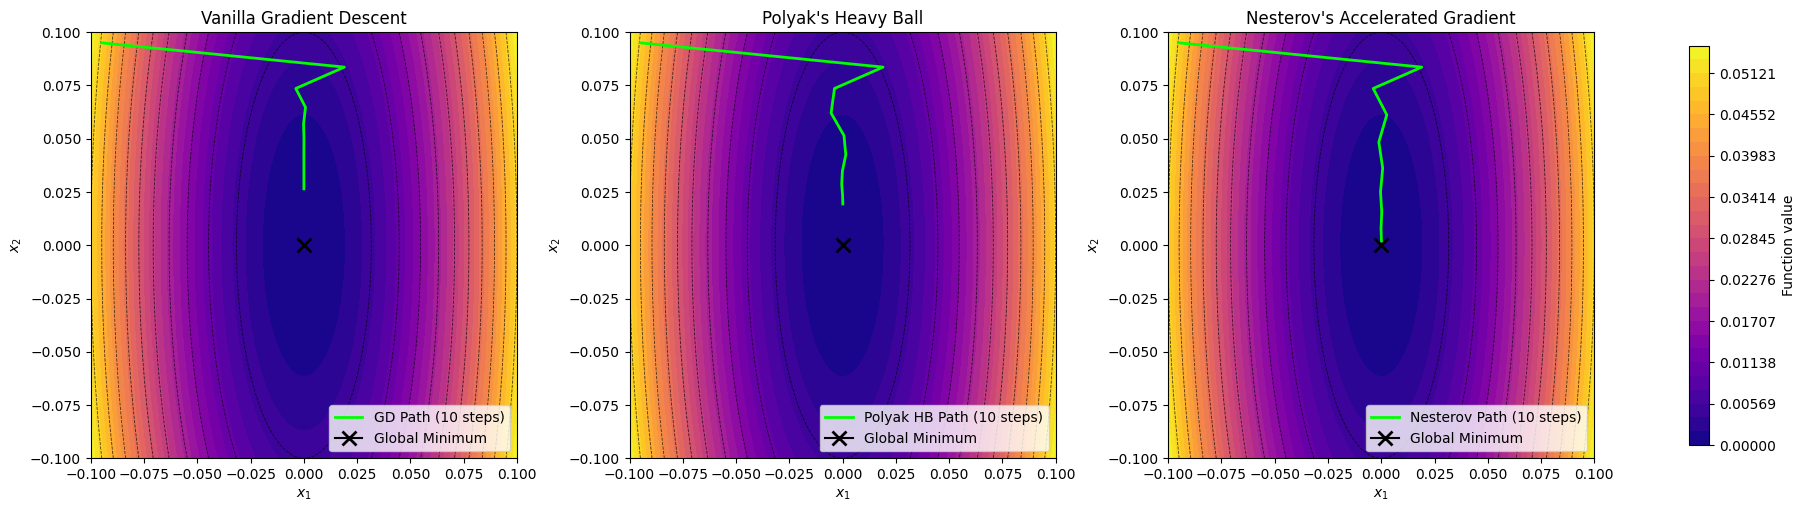

In [132]:
# Plot optimization paths

# Get min and max of Z for color scaling
z_min, z_max = Z.min(), Z.max()

fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Plot vanilla GD path on the left
axs[0].contourf(
    X, Y, Z, 
    levels=np.linspace(z_min, z_max, 30), 
    cmap="plasma", 
    vmin=z_min, vmax=z_max
)
axs[0].contour(X, Y, Z, levels=10, colors="k", linewidths=0.6, linestyles="--", alpha=0.7)
axs[0].set_title("Vanilla Gradient Descent")
axs[0].set_xlabel("$x_1$")
axs[0].set_ylabel("$x_2$")
axs[0].set_aspect('equal')
axs[0].plot(x_path_vanilla[:, 0], x_path_vanilla[:, 1], '-', color='lime', linewidth=2, label="GD Path (10 steps)")
# Place a black 'x' on the global minimum
axs[0].plot(x_star[0], x_star[1], marker='x', color='black', markersize=10, markeredgewidth=2, label="Global Minimum")
axs[0].legend(loc="lower right")

# Plot Polyak's Heavy Ball path in the middle
axs[1].contourf(
    X, Y, Z, 
    levels=np.linspace(z_min, z_max, 30), 
    cmap="plasma", 
    vmin=z_min, vmax=z_max
)
axs[1].contour(X, Y, Z, levels=10, colors="k", linewidths=0.6, linestyles="--", alpha=0.7)
axs[1].set_title("Polyak's Heavy Ball")
axs[1].set_xlabel("$x_1$")
axs[1].set_ylabel("$x_2$")
axs[1].set_aspect('equal')
axs[1].plot(x_path_phb[:, 0], x_path_phb[:, 1], '-', color='lime', linewidth=2, label="Polyak HB Path (10 steps)")
# Place a black 'x' on the global minimum
axs[1].plot(x_star[0], x_star[1], marker='x', color='black', markersize=10, markeredgewidth=2, label="Global Minimum")
axs[1].legend(loc="lower right")

# Plot Nesterov path on the right
contour = axs[2].contourf(  # Save for colorbar
    X, Y, Z,
    levels=np.linspace(z_min, z_max, 30),
    cmap="plasma",
    vmin=z_min, vmax=z_max
)
axs[2].contour(X, Y, Z, levels=10, colors="k", linewidths=0.6, linestyles="--", alpha=0.7)
axs[2].set_title("Nesterov's Accelerated Gradient")
axs[2].set_xlabel("$x_1$")
axs[2].set_ylabel("$x_2$")
axs[2].set_aspect('equal')
axs[2].plot(x_path_nest[:, 0], x_path_nest[:, 1], '-', color='lime', linewidth=2, label="Nesterov Path (10 steps)")
# Place a black 'x' on the global minimum
axs[2].plot(x_star[0], x_star[1], marker='x', color='black', markersize=10, markeredgewidth=2, label="Global Minimum")
axs[2].legend(loc="lower right")

# Add colorbar to the right of the three subplots, with color range matching min/max
fig.colorbar(contour, ax=axs, location='right', label="Function value", shrink=0.9, extend='both')
plt.show()
